Objectif : déterminer la survie des passagers du Titanic

#Import library

In [2]:
import pandas as pd
import numpy as np

# DataManagement
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

# Split train/test
from sklearn.model_selection import train_test_split

# Modèle
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC

# Evaluation
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, roc_auc_score

#Import files

In [3]:
!gdown 1Taahp0IbfqXUXZS6MgHCVkJyOIn-oFLe -O train.csv

Downloading...
From: https://drive.google.com/uc?id=1Taahp0IbfqXUXZS6MgHCVkJyOIn-oFLe
To: /content/train.csv
100% 61.2k/61.2k [00:00<00:00, 91.5MB/s]


In [4]:
!gdown 1_kfTQE3zR6VWAvv3iHKgKMnPUftbt6FQ -O test.csv

Downloading...
From: https://drive.google.com/uc?id=1_kfTQE3zR6VWAvv3iHKgKMnPUftbt6FQ
To: /content/test.csv
100% 27.8k/27.8k [00:00<00:00, 59.6MB/s]


In [5]:
df = pd.read_csv("train.csv", sep =",")
df_test = pd.read_csv("test.csv", sep = ";")
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


#DataManagement

In [6]:
#df['Embarked'].value_counts()
#df.isnull().sum()

,count
Embarked,
S,644
C,168
Q,77


In [8]:
numeric_features = ['Age']
categorical_features = ["Pclass", "Sex", "SibSp", "Parch", "Embarked"]

numeric_transformer = Pipeline([
    ('imputer', SimpleImputer(strategy='mean')),
    ('scaler', StandardScaler())
])

categorical_transformer = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OneHotEncoder(handle_unknown='ignore'))
])

preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_features),
        ('cat', categorical_transformer, categorical_features)
    ],
    remainder='drop'
)

# Split train/test

In [19]:
X = df.drop(columns=["Survived"])
y = df["Survived"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("Taille X_train :", X_train.shape)
print("Taille X_test :", X_test.shape)
print("Taille y_train :", y_train.shape)
print("Taille y_test :", y_test.shape)

Taille X_train : (712, 11)
Taille X_test : (179, 11)
Taille y_train : (712,)
Taille y_test : (179,)


In [10]:
X_train.head()

,PassengerId,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
331,332,1,"Partner, Mr. Austen",male,45.5,0,0,113043,28.5000,C124,S
733,734,2,"Berriman, Mr. William John",male,23.0,0,0,28425,13.0000,NaN,S
382,383,3,"Tikkanen, Mr. Juho",male,32.0,0,0,STON/O 2. 3101293,7.9250,NaN,S
704,705,3,"Hansen, Mr. Henrik Juul",male,26.0,1,0,350025,7.8542,NaN,S
813,814,3,"Andersson, Miss. Ebba Iris Alfrida",female,6.0,4,2,347082,31.2750,NaN,S


# Modèle

model = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', LogisticRegression(max_iter=500))
])

model.fit(X_train, y_train)

In [20]:
models = {
    'LogisticRegression': LogisticRegression(max_iter=500),
    'RandomForest': RandomForestClassifier(n_estimators=100, random_state=42),
    'SVM': SVC(probability=True)
}

In [21]:
results = {}

for name, clf in models.items():
    pipeline = Pipeline([
        ('preprocessor', preprocessor),
        ('classifier', clf)
    ])
    pipeline.fit(X_train, y_train)
    results[name] = pipeline

# Evaluation

In [22]:
for name, pipeline in results.items():
    print(f"\n=== Évaluation : {name} ===")
    y_pred = pipeline.predict(X_test)
    print(f"Accuracy : {accuracy_score(y_test, y_pred):.3f}")
    print(f"Precision : {precision_score(y_test, y_pred):.3f}")
    print(f"Recall : {recall_score(y_test, y_pred):.3f}")
    print(f"F1 score : {f1_score(y_test, y_pred):.3f}")
    print("Matrice de confusion :")
    print(confusion_matrix(y_test, y_pred))
    print("Classification report :")
    print(classification_report(y_test, y_pred))


=== Évaluation : LogisticRegression ===
Accuracy : 0.804
Precision : 0.793
Recall : 0.667
F1 score : 0.724
Matrice de confusion :
[[98 12]
 [23 46]]
Classification report :
              precision    recall  f1-score   support

           0       0.81      0.89      0.85       110
           1       0.79      0.67      0.72        69

    accuracy                           0.80       179
   macro avg       0.80      0.78      0.79       179
weighted avg       0.80      0.80      0.80       179


=== Évaluation : RandomForest ===
Accuracy : 0.799
Precision : 0.762
Recall : 0.696
F1 score : 0.727
Matrice de confusion :
[[95 15]
 [21 48]]
Classification report :
              precision    recall  f1-score   support

           0       0.82      0.86      0.84       110
           1       0.76      0.70      0.73        69

    accuracy                           0.80       179
   macro avg       0.79      0.78      0.78       179
weighted avg       0.80      0.80      0.80       179


===

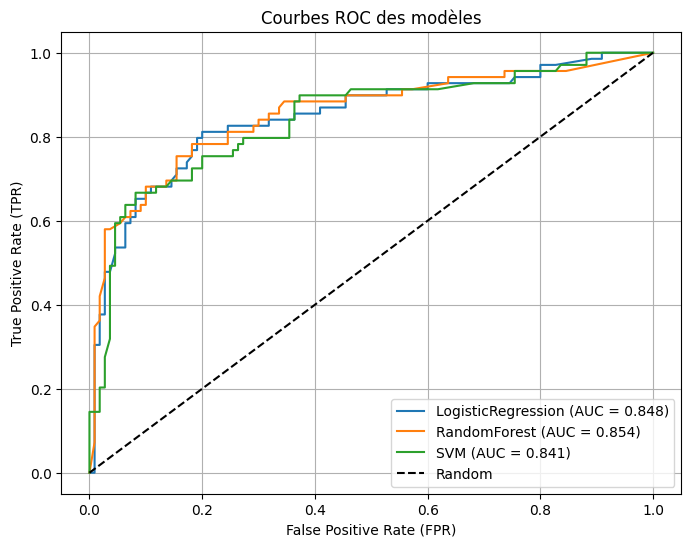

In [24]:
plt.figure(figsize=(8,6))

for name, pipeline in results.items():
    if hasattr(pipeline.named_steps['classifier'], "predict_proba"):
        y_proba = pipeline.predict_proba(X_test)[:,1]
    else:
        y_proba = pipeline.decision_function(X_test)

    fpr, tpr, thresholds = roc_curve(y_test, y_proba)
    auc_score = roc_auc_score(y_test, y_proba)

    plt.plot(fpr, tpr, label=f"{name} (AUC = {auc_score:.3f})")

plt.plot([0,1],[0,1],'k--', label='Random')
plt.xlabel("False Positive Rate (FPR)")
plt.ylabel("True Positive Rate (TPR)")
plt.title("ROC Curve")
plt.legend()
plt.grid(True)
plt.show()

# Test

In [16]:
df_test.head()

,PassengerId,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,892,3,"Kelly, Mr. James",male,34.5,0,0,330911,7.8292,NaN,Q
1,893,3,"Wilkes, Mrs. James (Ellen Needs)",female,47.0,1,0,363272,7.0000,NaN,S
2,894,2,"Myles, Mr. Thomas Francis",male,62.0,0,0,240276,9.6875,NaN,Q
3,895,3,"Wirz, Mr. Albert",male,27.0,0,0,315154,8.6625,NaN,S
4,896,3,"Hirvonen, Mrs. Alexander (Helga E Lindqvist)",female,22.0,1,1,3101298,12.2875,NaN,S


In [17]:
ID = df_test['PassengerId']
y_pred_new = results['LogisticRegression'].predict(df_test)

resultats_test = pd.DataFrame({
    'PassengerId': ID.values,
    'Survived': y_pred_new
})

resultats_test.head()

,PassengerId,Survived
0,892,0
1,893,0
2,894,0
3,895,0
4,896,1


In [18]:
resultats_test.to_csv('Final.csv', index=False)